In [10]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, precision_score, precision_recall_curve, recall_score
from src.evaluate import prepare_test_data, SAMPLE_FRAC

In [2]:
print("Carregando dataset...")
df_train = pd.read_csv("../data/processed/TEP_FaultFree_Training_Processed.csv")

# use only 5% of the data
print(f"Tamanho original: {len(df_train)}")
df_train = df_train.sample(frac=SAMPLE_FRAC, random_state=42)
print(f"Tamanho reduzido para o treino: {len(df_train)}")

Carregando dataset...
Tamanho original: 250000
Tamanho reduzido para o treino: 12500


In [3]:
print("Normalizando...")
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train)

del df_train
gc.collect()

Normalizando...


0

In [4]:
knn = NearestNeighbors(n_neighbors=6)
print("Modelo Carregado")

print("Treinando modelo...")
knn.fit(X_train)

Modelo Carregado
Treinando modelo...


NearestNeighbors(n_neighbors=6)

In [5]:
print("Calculating anomaly score on the training dataset")
distances_train, _ = knn.kneighbors(X_train)
anomaly_score_train = distances_train[:, 1:].mean(axis=1)

del X_train
gc.collect()

Calculating anomaly score on the training dataset


0

In [6]:
print("Loading test data...")
df_test = prepare_test_data()

y_true = df_test["Ground_Truth"].values
X_test = df_test.drop(columns=["Ground_Truth"])

X_test = scaler.transform(X_test)

del df_test
gc.collect()

Loading test data...
--- Preparando Dados de Teste ---
Carregando Normal...
Memória inicial: 9.89 MB
Memória final: 4.97 MB (49.8% redução)
Carregando Falhas (Isso pode demorar)...
Memória inicial: 197.75 MB
Memória final: 99.33 MB (49.8% redução)
Concatenando...
Dataset de teste final: 504000 linhas.
Distribuição: {1: 399985, 0: 104015}


0

In [7]:
print("Calculating anomaly score on the test dataset")
distances, _ = knn.kneighbors(X_test)
anomaly_score = distances[:, 1:].mean(axis=1)

threshold = np.percentile(anomaly_score_train, 95)

y_pred = (anomaly_score > threshold).astype(int)

Calculating anomaly score on the test dataset


In [8]:
print(classification_report(y_true, y_pred))
print(precision_score(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.95      0.62    104015
           1       0.98      0.71      0.82    399985

    accuracy                           0.76    504000
   macro avg       0.72      0.83      0.72    504000
weighted avg       0.87      0.76      0.78    504000

0.9814792915872508


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

6.221600174955777


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

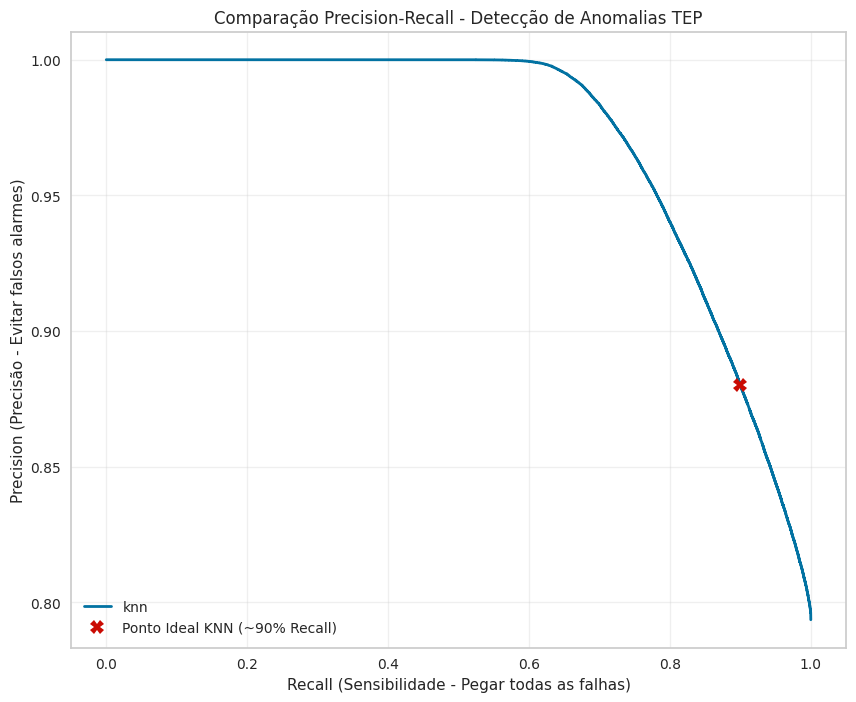

In [13]:
plt.figure(figsize=(10, 8))
    
precision, recall, thresholds = precision_recall_curve(y_true, anomaly_score)
        
plt.plot(recall, precision, label=f'knn', linewidth=2)
        
idx = (np.abs(recall - 0.90)).argmin() 

idx_thresh = min(idx, len(thresholds) - 1)
best_thresh = thresholds[idx_thresh]

plt.plot(recall[idx], precision[idx], 'rX', markersize=10, label='Ponto Ideal KNN (~90% Recall)')

plt.xlabel('Recall (Sensibilidade - Pegar todas as falhas)')
plt.ylabel('Precision (Precisão - Evitar falsos alarmes)')
plt.title('Comparação Precision-Recall - Detecção de Anomalias TEP')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

print(best_thresh)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

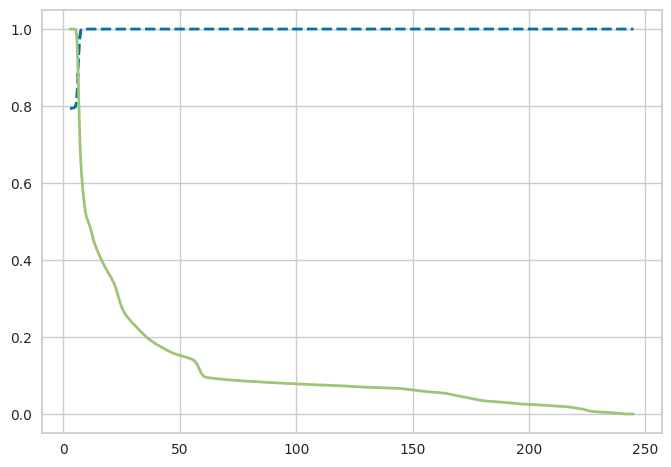

In [15]:
plt.plot(thresholds, precision[: -1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recall[: -1], "g-", label="Recall", linewidth=2)

In [14]:
# teste com novo threshold
threshold = best_thresh

y_pred = (anomaly_score > threshold).astype(int)

print(classification_report(y_true, y_pred))
print(precision_score(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.53      0.55    104015
           1       0.88      0.90      0.89    399985

    accuracy                           0.82    504000
   macro avg       0.73      0.71      0.72    504000
weighted avg       0.82      0.82      0.82    504000

0.8800172098947117
